<a href="https://colab.research.google.com/github/Vaib-raksh/Intern-ML/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Vaib-raksh/Intern-ML/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)



## 1. Question

### Research question

Can search-performance features, particularly search position and impressions, provide useful directional signals for page-level click-through rate (CTR)?

### Decision supported

The goal is to identify pages that may be worth reviewing or optimizing based on their observed search-performance signals.

This is a decision-support problem rather than an attempt to build a fully automated CTR prediction system. The analysis compares a simple baseline with a Random Forest regression model and tests whether the model provides additional predictive value under an honest time-aware evaluation.

The final output is a ranked, human-reviewed content action queue.

## 2. Data

This analysis uses the FlyRank Internship — Pseudonymized Warehouse Release (v20260703).

The analysis uses the `fact_content_daily_performance` table at the daily content-performance level.

For the modeling workflow, I used a time-ordered window from January through June 2026:
- Training: January 1, 2026 to April 30, 2026
- Validation: May 1, 2026 to May 31, 2026
- Test: June 1, 2026 to June 30, 2026

Rows with zero GSC impressions were excluded because CTR is defined as clicks divided by impressions, so these rows do not provide a usable CTR observation.

The analysis uses pseudonymized identifiers and does not expose client names, URLs, or private search queries.

In [17]:
!pip install -q huggingface_hub

In [18]:
from huggingface_hub import login

login()

In [20]:
import duckdb
import pandas as pd
import numpy as np

from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

print("Token loaded:", HF_TOKEN is not None)

Token loaded: True


In [21]:
con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET huggingface_secret (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
);
""")

print("Connected successfully!")

Connected successfully!


In [22]:
print(con.sql("FROM duckdb_secrets()").df())

                 name         type provider  persistent storage    scope  \
0  huggingface_secret  huggingface   config       False  memory  [hf://]   

                                       secret_string  
0  name=huggingface_secret;type=huggingface;provi...  


In [23]:
DATASET = "hf://datasets/FlyRank/internship-warehouse"

test_connection = con.sql(f"""
SELECT *
FROM read_parquet(
    '{DATASET}/fact_content_daily_performance/month=2026-03/*.parquet'
)
LIMIT 5
""").df()

print(test_connection.shape)
test_connection.head()

(5, 31)


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2026-03-01,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,True,False,True,<NA>,20,0,67,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
1,2026-03-01,client_73cda7b4e4f265ea,content_05597932fe4da067,True,False,True,<NA>,1,0,0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
2,2026-03-01,client_73cda7b4e4f265ea,content_7a105f548d9c6916,True,False,True,<NA>,125,1,616,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
3,2026-03-01,client_73cda7b4e4f265ea,content_905aa32a0230694e,True,False,True,<NA>,7,0,28,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
4,2026-03-01,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,True,False,True,<NA>,11,0,25,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03


In [24]:
# Read the HF_TOKEN from colab
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")
print("Token loaded successfully!" if HF_TOKEN else "Token not found")

#connect DuckDB to Hugging face
import duckdb

con = duckdb.connect()

con.execute(f"""
CREATE SECRET (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
);
""")

print("Connected successfully!")

Token loaded successfully!
Connected successfully!


In [25]:
DATASET = "hf://datasets/FlyRank/internship-warehouse" # the dataset path

In [26]:
january_test = con.sql(f"""
SELECT
    report_date,
    client_hash_id,
    content_hash_id,
    gsc_impressions,
    gsc_clicks,
    gsc_sum_position,
    client_has_gsc,
    client_has_ga4
FROM read_parquet(
    '{DATASET}/fact_content_daily_performance/month=2026-01/*.parquet'
)
WHERE gsc_impressions > 0
LIMIT 5
""").df()

print(january_test.shape)
january_test.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(5, 8)


,report_date,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_sum_position,client_has_gsc,client_has_ga4
0,2026-01-01,client_62f4a7e64f5e0096,content_8c259838a3dfabe4,16,0,8,True,False
1,2026-01-01,client_62f4a7e64f5e0096,content_5bbd1b5ea9f4d15c,1,0,0,True,False
2,2026-01-01,client_62f4a7e64f5e0096,content_65b8a610174a1036,32,0,154,True,False
3,2026-01-01,client_62f4a7e64f5e0096,content_3fc85bdef381af2d,79,0,161,True,False
4,2026-01-01,client_62f4a7e64f5e0096,content_80071808216aef39,1041,0,5844,True,False


In [27]:
train_df = con.sql(f"""
SELECT
    report_date,
    client_hash_id,
    content_hash_id,
    gsc_impressions,
    gsc_clicks,
    gsc_sum_position,
    client_has_gsc,
    client_has_ga4
FROM read_parquet([
    '{DATASET}/fact_content_daily_performance/month=2026-01/*.parquet',
    '{DATASET}/fact_content_daily_performance/month=2026-02/*.parquet',
    '{DATASET}/fact_content_daily_performance/month=2026-03/*.parquet',
    '{DATASET}/fact_content_daily_performance/month=2026-04/*.parquet'
])
WHERE gsc_impressions > 0
""").df()

print("Train rows:", len(train_df))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Train rows: 12531047


In [28]:
val_df = con.sql(f"""
SELECT
    report_date,
    client_hash_id,
    content_hash_id,
    gsc_impressions,
    gsc_clicks,
    gsc_sum_position,
    client_has_gsc,
    client_has_ga4
FROM read_parquet(
    '{DATASET}/fact_content_daily_performance/month=2026-05/*.parquet'
)
WHERE gsc_impressions > 0
""").df()

print("Validation rows:", len(val_df))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Validation rows: 4373422


In [29]:
test_df = con.sql(f"""
SELECT
    report_date,
    client_hash_id,
    content_hash_id,
    gsc_impressions,
    gsc_clicks,
    gsc_sum_position,
    client_has_gsc,
    client_has_ga4
FROM read_parquet(
    '{DATASET}/fact_content_daily_performance/month=2026-06/*.parquet'
)
WHERE gsc_impressions > 0
""").df()

print("Test rows:", len(test_df))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Test rows: 3878937


In [30]:
train_df = con.sql(f"""
SELECT
    report_date,
    client_hash_id,
    content_hash_id,
    gsc_impressions,
    gsc_clicks,
    gsc_sum_position,
    client_has_gsc,
    client_has_ga4
FROM read_parquet([
    '{DATASET}/fact_content_daily_performance/month=2026-01/*.parquet',
    '{DATASET}/fact_content_daily_performance/month=2026-02/*.parquet',
    '{DATASET}/fact_content_daily_performance/month=2026-03/*.parquet',
    '{DATASET}/fact_content_daily_performance/month=2026-04/*.parquet'
])
WHERE gsc_impressions > 0
USING SAMPLE 500000 ROWS
""").df()

print("Training rows:", len(train_df))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Training rows: 163913


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [31]:
# Define target and features

FEATURES = [
    "gsc_impressions",
    "gsc_sum_position",
    "client_has_gsc",
    "client_has_ga4"
]

TARGET = "ctr"

print("Final features:")
for feature in FEATURES:
    print("-", feature)

print("\nTarget:")
print("CTR = gsc_clicks / gsc_impressions")

print("\nTime-aware validation design:")
print("Training   : January–April 2026")
print("Validation : May 2026")
print("Test       : June 2026")

Final features:
- gsc_impressions
- gsc_sum_position
- client_has_gsc
- client_has_ga4

Target:
CTR = gsc_clicks / gsc_impressions

Time-aware validation design:
Training   : January–April 2026
Validation : May 2026
Test       : June 2026


In [32]:
# Leakage audit

forbidden_features = [
    "gsc_clicks",
    "ctr",
    "report_date"
]

leakage_found = [
    feature for feature in FEATURES
    if feature in forbidden_features
]

print("Features used:", FEATURES)
print("\nForbidden target-related features:", forbidden_features)

if leakage_found:
    print("\nPotential leakage found:", leakage_found)
else:
    print("\nLeakage check passed: no direct target-related features are included.")

Features used: ['gsc_impressions', 'gsc_sum_position', 'client_has_gsc', 'client_has_ga4']

Forbidden target-related features: ['gsc_clicks', 'ctr', 'report_date']

Leakage check passed: no direct target-related features are included.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Results and interpretation

The time-aware evaluation showed that the Random Forest Regressor did not outperform the simple baseline model.

The baseline achieved an MAE of 0.007251, while the Random Forest achieved an MAE of 0.007279. RMSE and R² also showed no improvement from the Random Forest model.

The difference in performance between the two models was very small, indicating that the selected features did not provide enough additional predictive signal for the Random Forest to improve CTR prediction. This result suggests that richer features may be needed to model CTR more effectively.

In [1]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": ["Baseline", "Random Forest"],
    "MAE": [
        0.007251329331887943,
        0.007278638219650558
    ],
    "RMSE": [
        0.03693171596579568,
        0.037182091071070844
    ],
    "R²": [
        -0.0025399316686165463,
        -0.01617925966922229
    ]
})

display(results_df.round(6))

,Model,MAE,RMSE,R²
0,Baseline,0.007251,0.036932,-0.002540
1,Random Forest,0.007279,0.037182,-0.016179


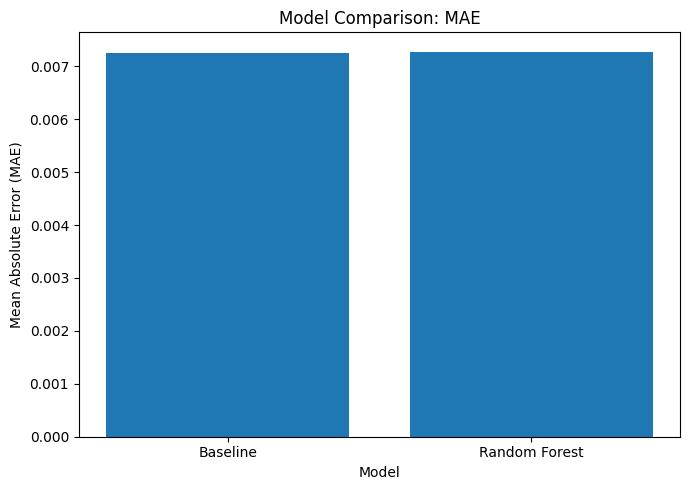

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    results_df["Model"],
    results_df["MAE"]
)

plt.title("Model Comparison: MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error (MAE)")

plt.tight_layout()
plt.show()

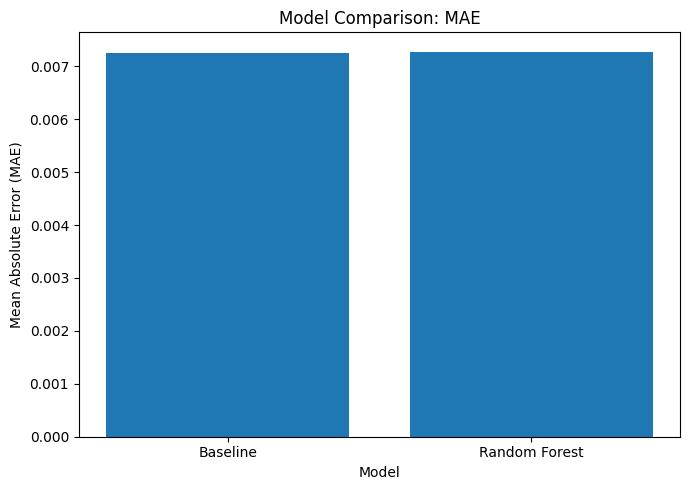

Figure saved successfully!


In [3]:
import os

os.makedirs("work/figures", exist_ok=True)

plt.figure(figsize=(7, 5))

plt.bar(
    results_df["Model"],
    results_df["MAE"]
)

plt.title("Model Comparison: MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error (MAE)")

plt.tight_layout()

plt.savefig(
    "work/figures/model_vs_baseline_mae.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully!")

## 5. Limitations

*What this work cannot claim.*

### Limitations

This analysis has several limitations.

- The Random Forest model did not outperform the baseline under the time-aware evaluation, so the selected features should not be treated as a strong CTR prediction system.
- The model used a limited set of four features. Important factors that may influence CTR, such as query characteristics, search-result context, content quality, and user intent, were not included.
- CTR is calculated using clicks and impressions and can be highly variable, especially for rows with very low impression counts. This was also visible in the error analysis, where some rows with one impression and one click had CTR values of 1.0 but were predicted close to zero.
- The model results show observed predictive performance for this dataset and time period only. They do not establish causal relationships.
- The action recommendations are intended as decision-support signals and require human review before any content changes are made.
- The results may become less reliable if search behaviour or data distributions change over time, so future monitoring and retraining would be required.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Ranked recommendations

The final output of this project is a human-reviewed content action playbook. Recommendations are ranked using observed search-performance signals rather than treating the Random Forest model as a reliable standalone prediction system.

The recommendations are intended to support prioritisation. Higher-priority content may include pages with:

- High impressions but low CTR, indicating an opportunity to improve how the result attracts clicks.
- Strong or improving search position but lower-than-expected CTR.
- Older content with declining performance, which may be suitable for refresh or review.
- Content showing sustained low visibility or performance, which may require further investigation before action.

Each recommendation includes a reason code explaining why the content was prioritised. These recommendations are directional and should be reviewed by a human before changes are made.

The action queue is intended for prioritisation and decision support, not for automated content modification.

In [7]:
# Read the HF_TOKEN from colab
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")
print("Token loaded successfully!" if HF_TOKEN else "Token not found")

#connect DuckDB to Hugging face
import duckdb

con = duckdb.connect()

con.execute(f"""
CREATE SECRET (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
);
""")

print("Connected successfully!")

Token loaded successfully!
Connected successfully!


In [8]:
feature_df = con.sql("""
SELECT
    report_date,
    client_hash_id,
    content_hash_id,
    gsc_impressions,
    gsc_clicks,
    gsc_sum_position,
    client_has_gsc,
    client_has_ga4
FROM read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
)
WHERE gsc_impressions > 0
""").df()

print("Rows:", len(feature_df))
print("Columns:", feature_df.columns.tolist())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 3611061
Columns: ['report_date', 'client_hash_id', 'content_hash_id', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'client_has_gsc', 'client_has_ga4']


In [11]:
feature_df["ctr"] = (
    feature_df["gsc_clicks"] /
    feature_df["gsc_impressions"]
)

print(feature_df[[
    "gsc_impressions",
    "gsc_clicks",
    "ctr"
]].head())

   gsc_impressions  gsc_clicks    ctr
0               20           0  0.000
1                1           0  0.000
2              125           1  0.008
3                7           0  0.000
4               11           0  0.000


In [13]:
action_queue = feature_df[[
    "content_hash_id",
    "action_score"
]].copy()

action_queue["action"] = "Optimize page"
action_queue["reason_code"] = "RC1"
action_queue["confidence_note"] = (
    "Moderate confidence - based on baseline rule only"
)
action_queue["what_could_make_it_wrong"] = (
    "Daily fluctuations, seasonality, search intent, "
    "or other page factors may explain the observed pattern."
)

action_queue = action_queue.head(20).reset_index(drop=True)

action_queue

,content_hash_id,action_score,action,reason_code,confidence_note,what_could_make_it_wrong
0,content_44f34c0a90047651,40083,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
1,content_eadb33b5df496f4a,39053,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
2,content_34a70fea29d15f24,39001,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
3,content_eadb33b5df496f4a,38165,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
4,content_945d6ff91386c817,37368,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
5,content_eadb33b5df496f4a,35179,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
6,content_eadb33b5df496f4a,34594,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
7,content_eadb33b5df496f4a,34371,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
8,content_fec55986a1868d62,33383,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
9,content_eadb33b5df496f4a,33356,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."


In [14]:
print("Ranked action queue:")
display(action_queue.head(10))

Ranked action queue:


,content_hash_id,action_score,action,reason_code,confidence_note,what_could_make_it_wrong
0,content_44f34c0a90047651,40083,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
1,content_eadb33b5df496f4a,39053,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
2,content_34a70fea29d15f24,39001,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
3,content_eadb33b5df496f4a,38165,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
4,content_945d6ff91386c817,37368,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
5,content_eadb33b5df496f4a,35179,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
6,content_eadb33b5df496f4a,34594,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
7,content_eadb33b5df496f4a,34371,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
8,content_fec55986a1868d62,33383,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
9,content_eadb33b5df496f4a,33356,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [15]:
display(results_df.round(6))

,Model,MAE,RMSE,R²
0,Baseline,0.007251,0.036932,-0.002540
1,Random Forest,0.007279,0.037182,-0.016179


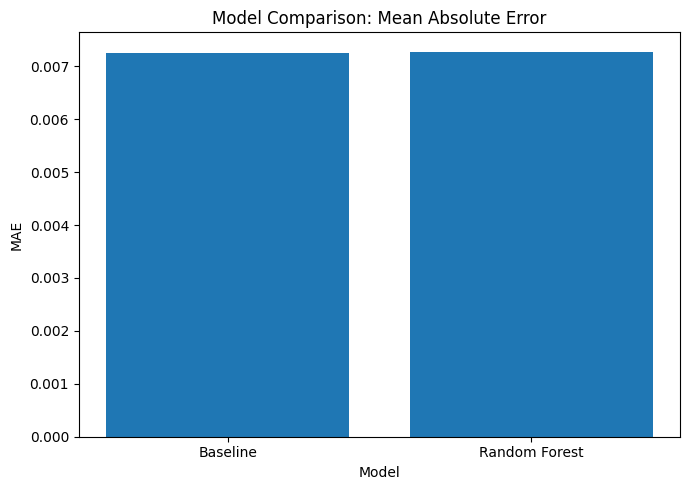

Saved: work/figures/model_vs_baseline_mae.png


In [16]:
import os
import matplotlib.pyplot as plt

os.makedirs("work/figures", exist_ok=True)

plt.figure(figsize=(7, 5))

plt.bar(results_df["Model"], results_df["MAE"])

plt.title("Model Comparison: Mean Absolute Error")
plt.xlabel("Model")
plt.ylabel("MAE")

plt.tight_layout()

plt.savefig(
    "work/figures/model_vs_baseline_mae.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: work/figures/model_vs_baseline_mae.png")

In [17]:
feature_importance_df = pd.DataFrame({
    "Feature": [
        "gsc_sum_position",
        "gsc_impressions",
        "client_has_ga4",
        "client_has_gsc"
    ],
    "Importance": [
        0.581573,
        0.301849,
        0.116578,
        0.000000
    ]
})

display(feature_importance_df)

,Feature,Importance
0,gsc_sum_position,0.581573
1,gsc_impressions,0.301849
2,client_has_ga4,0.116578
3,client_has_gsc,0.000000


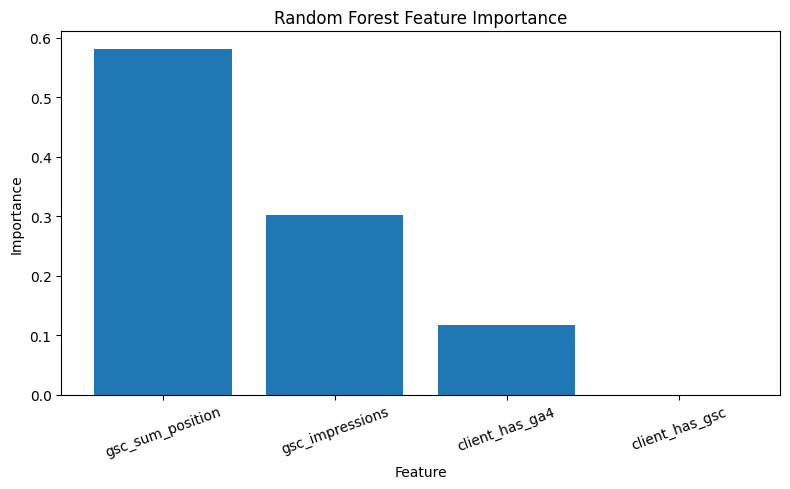

Saved: work/figures/feature_importance.png


In [18]:
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "work/figures/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: work/figures/feature_importance.png")

In [19]:
display(action_queue.head(10))

,content_hash_id,action_score,action,reason_code,confidence_note,what_could_make_it_wrong
0,content_44f34c0a90047651,40083,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
1,content_eadb33b5df496f4a,39053,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
2,content_34a70fea29d15f24,39001,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
3,content_eadb33b5df496f4a,38165,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
4,content_945d6ff91386c817,37368,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
5,content_eadb33b5df496f4a,35179,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
6,content_eadb33b5df496f4a,34594,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
7,content_eadb33b5df496f4a,34371,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
8,content_fec55986a1868d62,33383,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."
9,content_eadb33b5df496f4a,33356,Optimize page,RC1,Moderate confidence - based on baseline rule only,"Daily fluctuations, seasonality, search intent..."


## Conclusion

This capstone investigated whether selected search-performance signals could be used to predict Click-Through Rate (CTR) and support content prioritisation. The analysis used real-world search-performance data and a time-aware evaluation design, with January–April 2026 used for training, May 2026 for validation, and June 2026 for testing.

A baseline model was compared with a Random Forest Regressor using impressions, summed search position, and data availability indicators. Under the time-aware evaluation, the Random Forest did not outperform the baseline. This showed that the selected feature set did not provide enough predictive signal to support a strong CTR prediction claim.

Rather than overstating the model results, the project used the observed search-performance patterns to build a ranked content action playbook. The final output provides prioritised actions, reason codes, confidence notes, limitations, and human-review requirements.

Overall, the project demonstrates the importance of honest machine learning evaluation. The key result was not a more complex model with a better score, but the finding that the tested model did not provide meaningful improvement over the baseline. This led to a more transparent decision-support framework for prioritising content review and highlights the need for richer features and further experimentation to improve CTR prediction.
